# Deteccion de Anomalias - Autoencoder LSTM (Google Colab GPU)

Notebook para **entrenar** el modelo en Google Colab con GPU.
Una vez entrenado, descarga los ficheros del modelo y usalo en local
con el script `anomalias_autoencoder.py` (solo inferencia, sin GPU).

**Flujo:**
1. Entrena el modelo aqui (Colab GPU)
2. Descarga `autoencoder_lstm.keras` + `ae_umbral.pkl`
3. Colocalos en `models/` de tu proyecto local
4. Ejecuta `anomalias_autoencoder.py` -> detecta automaticamente el modelo y solo hace inferencia


## 1. Verificacion de GPU

In [1]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Usando GPU: {gpus[0].name}")
else:
    print("No GPU detectada. Cambia el entorno: Entorno de ejecucion > Cambiar tipo > GPU")


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Usando GPU: /physical_device:GPU:0


## 2. Montar Google Drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

# Ajusta esta ruta a tu carpeta en Drive
DRIVE_PROJECT = "/content/drive/MyDrive/Instituto/Inteligencia Artificial y Big Data/TFE/mercaintelligence"


Mounted at /content/drive


## 3. Imports

In [3]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


## 4. Rutas y parametros

In [4]:
PARTITIONED_DIR = Path(f"{DRIVE_PROJECT}/data/processed")
MODEL_PATH      = Path(f"{DRIVE_PROJECT}/models/autoencoder_lstm.keras")
UMBRAL_PATH     = Path(f"{DRIVE_PROJECT}/models/ae_umbral.pkl")
IMG_DIR         = Path(f"{DRIVE_PROJECT}/docs/img/autoencoder")

IMG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

VENTANA          = 14
N_FEATURES       = 3
MIN_DIAS         = 20
EPOCHS           = 30
BATCH_SIZE       = 64
VALIDATION_SPLIT = 0.1
PERCENTIL_UMBRAL_INFERENCIA = 99

print("Configuracion cargada")
print(f"  Datos:  {PARTITIONED_DIR}")
print(f"  Modelo: {MODEL_PATH}")


Configuracion cargada
  Datos:  /content/drive/MyDrive/Instituto/Inteligencia Artificial y Big Data/TFE/mercaintelligence/data/processed
  Modelo: /content/drive/MyDrive/Instituto/Inteligencia Artificial y Big Data/TFE/mercaintelligence/models/autoencoder_lstm.keras


## 5. Carga y preparacion de datos

In [5]:
cols = [
    "referencia", "fecha", "precio_actual", "precio_por_medida",
    "categoria", "subcategoria", "titulo", "marca_propia",
]
df = pd.read_parquet(PARTITIONED_DIR, columns=cols)
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values(["referencia", "fecha"]).reset_index(drop=True)

# Feature engineering
df["precio_anterior"] = df.groupby("referencia")["precio_actual"].shift(1)
df["variacion_pct"] = (
    ((df["precio_actual"] - df["precio_anterior"]) / df["precio_anterior"])
    .fillna(0.0).round(6)
)
df["precio_cambio"] = (
    df.groupby("referencia")["precio_actual"].shift(1) != df["precio_actual"]
)
df["grupo_cambio"] = df.groupby("referencia")["precio_cambio"].cumsum()
df["dias_sin_cambio"] = df.groupby(["referencia", "grupo_cambio"]).cumcount()
df = df.drop(columns=["precio_anterior", "precio_cambio", "grupo_cambio"])

n_filas = len(df)
n_prods = df["referencia"].nunique()
print(f"Datos: {n_filas:,} filas | {n_prods:,} productos")
df.head()


Datos: 763,435 filas | 5,101 productos


,referencia,fecha,precio_actual,precio_por_medida,categoria,subcategoria,titulo,marca_propia,variacion_pct,dias_sin_cambio
0,1393,2025-11-03,2.62,7.5,carne,embutido,botifarrón de carne,comercial,0.0,0
1,1393,2025-11-08,2.62,7.5,carne,embutido,botifarrón de carne,comercial,0.0,1
2,1393,2025-11-09,2.62,7.5,carne,embutido,botifarrón de carne,comercial,0.0,2
3,1393,2025-11-13,2.62,7.5,carne,embutido,botifarrón de carne,comercial,0.0,3
4,1393,2025-11-14,2.62,7.5,carne,embutido,botifarrón de carne,comercial,0.0,4


## 6. Normalizacion min-max por producto

In [6]:
for col in ["precio_actual", "dias_sin_cambio"]:
    min_val = df.groupby("referencia")[col].transform("min")
    max_val = df.groupby("referencia")[col].transform("max")
    rango = (max_val - min_val).replace(0, 1)
    df[f"{col}_norm"] = ((df[col] - min_val) / rango).round(6)

print("Normalizacion completada")


Normalizacion completada


## 7. Construccion de secuencias de entrenamiento (normales)

In [7]:
def construir_secuencias(df, solo_normales=False):
    features = ["precio_actual_norm", "variacion_pct", "dias_sin_cambio_norm"]
    X, meta = [], []
    for ref, grupo in df.groupby("referencia"):
        grupo = grupo.sort_values("fecha").reset_index(drop=True)
        if len(grupo) < MIN_DIAS:
            continue
        vals = grupo[features].values
        for i in range(VENTANA, len(grupo)):
            secuencia = vals[i - VENTANA : i]
            if solo_normales and np.any(secuencia[:, 1] != 0):
                continue
            X.append(secuencia)
            meta.append((ref, grupo["fecha"].iloc[i]))
    return np.array(X, dtype=np.float32), meta

X_train, _ = construir_secuencias(df, solo_normales=True)
print(f"Secuencias normales: {len(X_train):,}")
print(f"Shape: {X_train.shape}")


Secuencias normales: 642,396
Shape: (642396, 14, 3)


## 8. Arquitectura del Autoencoder LSTM

In [8]:
inputs = Input(shape=(VENTANA, N_FEATURES), name="input_secuencia")
# Encoder
x = LSTM(64, return_sequences=True, name="encoder_lstm1")(inputs)
x = LSTM(32, return_sequences=False, name="encoder_lstm2")(x)
# Bottleneck
x = RepeatVector(VENTANA, name="bottleneck")(x)
# Decoder
x = LSTM(32, return_sequences=True, name="decoder_lstm1")(x)
x = LSTM(64, return_sequences=True, name="decoder_lstm2")(x)
outputs = TimeDistributed(Dense(N_FEATURES), name="output")(x)

modelo = Model(inputs, outputs, name="autoencoder_lstm")
modelo.compile(optimizer="adam", loss="mse")
modelo.summary()


Model: "autoencoder_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_secuencia (InputLayer)    │ (None, 14, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm1 (LSTM)            │ (None, 14, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm2 (LSTM)            │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (RepeatVector)       │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm1 (LSTM)            │ (None, 14, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm2 (LSTM)            │ (None, 14, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 14, 3)          │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,171 (246.76 KB)

 Trainable params: 63,171 (246.76 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Entrenamiento con GPU

El entrenamiento se ejecuta automaticamente en la GPU asignada por Colab.


In [9]:
history = modelo.fit(
    X_train, X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks = [
        EarlyStopping(
            monitor="val_loss", patience=5,
            restore_best_weights=True, verbose=1,
        ),
        ModelCheckpoint(str(MODEL_PATH), save_best_only=True, verbose=0),
    ],
)

print(f"\n✅ Modelo entrenado y guardado en {MODEL_PATH}")

Epoch 1/30
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 111s 12ms/step - loss: 3.8958e-04 - val_loss: 5.9080e-06
Epoch 2/30
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 104s 11ms/step - loss: 9.6551e-06 - val_loss: 1.3680e-05
Epoch 3/30
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 109s 12ms/step - loss: 7.8477e-06 - val_loss: 2.3831e-06
Epoch 4/30
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 104s 12ms/step - loss: 4.3158e-06 - val_loss: 8.8745e-07
Epoch 5/30
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 104s 12ms/step - loss: 3.5435e-06 - val_loss: 6.4480e-06
Epoch 6/30
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 108s 12ms/step - loss: 3.1984e-06 - val_loss: 3.3480e-06
Epoch 7/30
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 108s 12ms/step - loss: 2.5384e-06 - val_loss: 8.8142e-07
Epoch 8/30
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 105s 12ms/step - loss: 2.1730e-06 - val_loss: 1.7984e-07
Epoch 9/30
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 103s 11ms/step - loss: 1.8473e-06 - val_loss: 8.4847e-07
Epoch 10/30
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 104s 11ms/step - loss: 1.6480e-06 - val_loss: 9.9913e-07
Epoch 11/

## 10. Curvas de entrenamiento

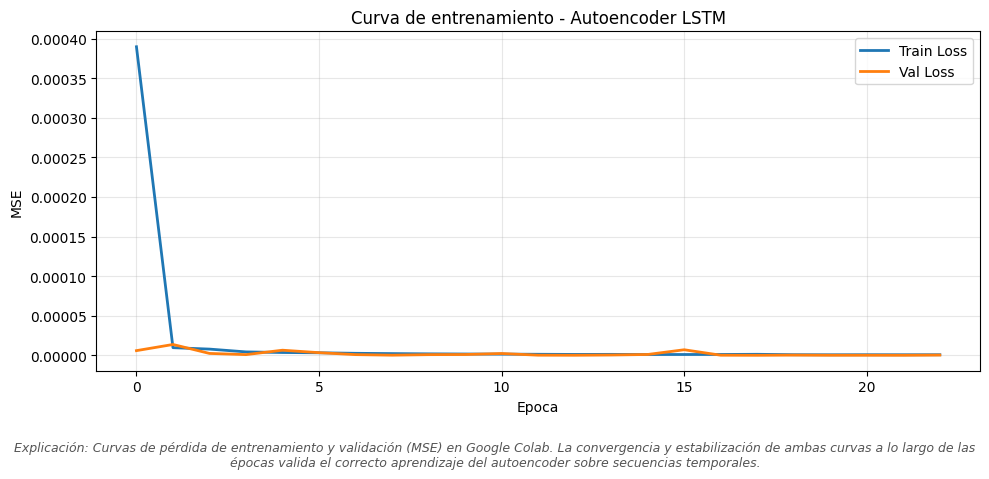

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(history.history["loss"], label="Train Loss", linewidth=2)
ax.plot(history.history["val_loss"], label="Val Loss", linewidth=2)
ax.set_xlabel("Epoca")
ax.set_ylabel("MSE")
ax.set_title("Curva de entrenamiento - Autoencoder LSTM")
ax.legend()
ax.grid(True, alpha=0.3)

caption = "Explicación: Curvas de pérdida de entrenamiento y validación (MSE) en Google Colab. La convergencia y estabilización de ambas curvas a lo largo de las épocas valida el correcto aprendizaje del autoencoder sobre secuencias temporales."
plt.figtext(0.5, 0.01, caption, wrap=True, horizontalalignment='center', fontsize=9, style='italic', color='#555555')
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig(IMG_DIR / "ae_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Calculo del umbral de anomalia

In [16]:
X_pred_train = modelo.predict(X_train, verbose=0)
errores_train = np.mean(np.square(X_train - X_pred_train), axis=(1, 2))

err_mean = float(errores_train.mean())
err_std  = float(errores_train.std())

print("Distribucion del error de reconstruccion (train):")
print(f"  Media  : {err_mean:.10f}")
print(f"  Std    : {err_std:.10f}")
print(f"  Min    : {errores_train.min():.10f}")
print(f"  Max    : {errores_train.max():.10f}")

# (El umbral real se calcula sobre los datos de inferencia en la seccion 14)

Distribucion del error de reconstruccion (train):
  Media  : 0.0000000343
  Std    : 0.0000001706
  Min    : 0.0000000021
  Max    : 0.0000120259


## 12. Distribucion del error de reconstruccion

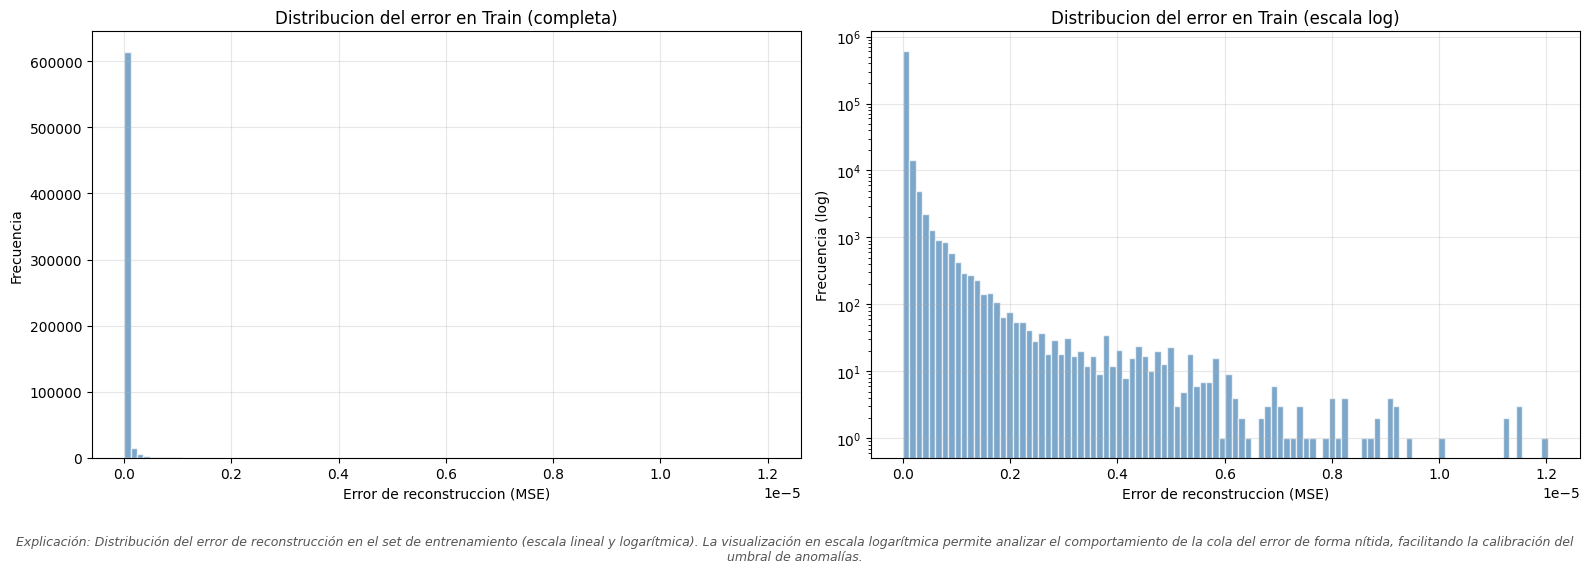

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma completo
axes[0].hist(errores_train, bins=100, alpha=0.7, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Error de reconstruccion (MSE)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribucion del error en Train (completa)")
axes[0].grid(True, alpha=0.3)

# Histograma con escala log para ver la cola
axes[1].hist(errores_train, bins=100, alpha=0.7, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Error de reconstruccion (MSE)")
axes[1].set_ylabel("Frecuencia (log)")
axes[1].set_title("Distribucion del error en Train (escala log)")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

caption = "Explicación: Distribución del error de reconstrucción en el set de entrenamiento (escala lineal y logarítmica). La visualización en escala logarítmica permite analizar el comportamiento de la cola del error de forma nítida, facilitando la calibración del umbral de anomalías."
plt.figtext(0.5, 0.01, caption, wrap=True, horizontalalignment='center', fontsize=9, style='italic', color='#555555')
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig(IMG_DIR / "ae_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Verificacion: inferencia rapida de prueba

In [18]:
# Prueba rapida de inferencia para verificar que el modelo funciona
X_all, meta = construir_secuencias(df, solo_normales=False)
print(f"Secuencias totales: {len(X_all):,}")

X_pred = modelo.predict(X_all, batch_size=256, verbose=1)
errores = np.mean(np.square(X_all - X_pred), axis=(1, 2))

# =========================================================
# CALCULO Y GUARDADO DEL UMBRAL DEFINITIVO
# Se usa P99 de la distribucion bimodal real de inferencia
# =========================================================
umbral = float(np.percentile(errores, PERCENTIL_UMBRAL_INFERENCIA))

umbral_data = {
    "umbral": umbral,
    "metodo": f"percentil_{PERCENTIL_UMBRAL_INFERENCIA}_inferencia"
}
joblib.dump(umbral_data, UMBRAL_PATH)
print(f"\nUmbral P{PERCENTIL_UMBRAL_INFERENCIA} calculado y guardado en {UMBRAL_PATH}")

print("\nDistribucion error inferencia:")
print(f"  Media: {errores.mean():.10f} | Std: {errores.std():.10f}")
print(f"  Min:   {errores.min():.10f} | Max: {errores.max():.10f}")
print(f"  Umbral aplicado: {umbral:.10f}")

n_anomalias = (errores > umbral).sum()
tasa = n_anomalias / len(errores) * 100

print(f"\nAnomalias detectadas: {n_anomalias:,} ({tasa:.2f}%)")
print("\nEl modelo funciona correctamente. Ya puedes descargar `autoencoder_lstm.keras` y `ae_umbral.pkl`.")


Secuencias totales: 692,816
2707/2707 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step

Umbral P99 calculado y guardado en /content/drive/MyDrive/Instituto/Inteligencia Artificial y Big Data/TFE/mercaintelligence/models/ae_umbral.pkl

Distribucion error inferencia:
  Media: 0.0051696859 | Std: 0.0235188603
  Min:   0.0000000021 | Max: 0.1983879805
  Umbral aplicado: 0.1410443187

Anomalias detectadas: 6,929 (1.00%)

El modelo funciona correctamente. Ya puedes descargar `autoencoder_lstm.keras` y `ae_umbral.pkl`.


## 13. Descargar modelo para uso local

Descarga estos 2 ficheros y colocalos en la carpeta `models/` de tu proyecto local:

```
mercaintelligence/
  models/
    autoencoder_lstm.keras   <-- modelo entrenado
    ae_umbral.pkl            <-- umbral de anomalia
```

Despues ejecuta `python src/ml/anomalias_autoencoder.py` en local.
El script detectara automaticamente el modelo y hara solo inferencia (sin GPU).


### Opcion A: Si usas Google Drive (ya estan guardados)

In [19]:
# Los ficheros ya estan en tu Drive:
print(f"Modelo: {MODEL_PATH}")
print(f"Umbral: {UMBRAL_PATH}")
print(f"\nModel exists: {MODEL_PATH.exists()}")
print(f"Umbral exists: {UMBRAL_PATH.exists()}")
print("\nDescarga estos ficheros desde Google Drive a tu carpeta models/ local")


Modelo: /content/drive/MyDrive/Instituto/Inteligencia Artificial y Big Data/TFE/mercaintelligence/models/autoencoder_lstm.keras
Umbral: /content/drive/MyDrive/Instituto/Inteligencia Artificial y Big Data/TFE/mercaintelligence/models/ae_umbral.pkl

Model exists: True
Umbral exists: True

Descarga estos ficheros desde Google Drive a tu carpeta models/ local
